#  Projet Machine Learning avec <a href="https://cran.r-project.org/"><img src="https://cran.r-project.org/Rlogo.svg" style="max-width: 40px; display: inline" alt="R"/></a>

## 1. Analyse exploratoire des données

In [20]:
install.packages(c("GGally","plotly","corrplot","reshape2","FactoMineR","factoextra","glmnet","ggfortify","pROC","ROCR"), dependencies = TRUE)


Warning message:
"les packages 'GGally', 'plotly', 'corrplot', 'reshape2', 'FactoMineR', 'factoextra', 'glmnet', 'ggfortify', 'pROC', 'ROCR' sont en cours d'utilisation et ne seront pas installés"


In [21]:
install.packages("ggplot2", repos = "https://cloud.r-project.org/")


Warning message:
"le package 'ggplot2' est en cours d'utilisation et ne sera pas installé"


In [40]:
install.packages("caret")

Installation du package dans 'C:/Users/aivan/AppData/Local/R/win-library/4.5'
(car 'lib' n'est pas spécifié)

installation des dépendances 'listenv', 'parallelly', 'future', 'globals', 'future.apply', 'progressr', 'SQUAREM', 'diagram', 'lava', 'prodlim', 'proxy', 'clock', 'gower', 'hardhat', 'ipred', 'sparsevctrs', 'e1071', 'ModelMetrics', 'recipes'





  Des versions binaires sont disponibles mais les versions des sources
  sont plus récentes:
          binary source needs_compilation
progressr 0.18.0 0.19.0             FALSE
lava       1.8.2  1.9.0             FALSE
hardhat    1.4.2  1.4.3             FALSE
recipes    1.3.1  1.3.2             FALSE

le package 'listenv' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'parallelly' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'future' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'globals' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'future.apply' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'SQUAREM' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'diagram' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'prodlim' a été décompressé et les sommes MD5 ont été vérifiées avec

installation des packages sources 'progressr', 'lava', 'hardhat', 'recipes'




In [1]:
# Chargement des librairies nécessaires
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(MASS) # chargement des librairies
library(class) # pour kNN

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : 'gridExtra'


L'objet suivant est masqué depuis 'package:dplyr':

    combine



Attachement du package : 'plotly'


L'objet suivant est masqué depuis 'package:ggplot2':

    last_plot


L'objet suivant est masqué depuis 'package:stats':

    filter


L'objet suivant est masqué depuis 'package:graphics':

    layout


corrplot 0.95 loaded


Attachement du package : 'reshape2'


L'objet suiv

# Lecture des données 

In [2]:
# Lecture des données
path <- ""
health <- read.csv(paste(path, "healthcare_synthetic_data.csv", sep = ""),
                    sep = ",", header = TRUE)
# Premières lignes du jeu de données
head(health)
# Vérification du contenu
summary(health)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

## Changement du type des variables qualitatives en facteur

In [3]:
# Changement du type des variables qualitatives en facteur
health[, "Gender"] <- as.factor(health[, "Gender"])
health[, "Smoking_Status"] <- as.factor(health[, "Smoking_Status"])
health[, "Alcohol_Consumption"] <- as.factor(health[, "Alcohol_Consumption"])
health[, "Physical_Activity_Level"] <- as.factor(health[, "Physical_Activity_Level"])
health[, "Family_History"] <- as.factor(health[, "Family_History"])
health[, "Stress_Level"] <- as.factor(health[, "Stress_Level"])
health[, "Heart_Disease_Risk"] <- as.factor(health[, "Heart_Disease_Risk"])
health[, "Sleep_Hours"] <- as.factor(health[, "Sleep_Hours"])


In [4]:
summary(health)

  Patient_ID             Age        Gender     Height_cm       Weight_kg     
 Length:15000       Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70  
 Class :character   1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20  
 Mode  :character   Median :55.00            Median :164.7   Median : 73.90  
                    Mean   :54.54            Mean   :165.3   Mean   : 75.25  
                    3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90  
                    Max.   :85.00            Max.   :198.1   Max.   :150.10  
                                                                             
      BMI         Systolic_BP     Diastolic_BP    Cholesterol_Total
 Min.   :14.50   Min.   : 90.0   Min.   : 60.00   Min.   :127.0    
 1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0    
 Median :27.20   Median :135.0   Median : 91.00   Median :216.0    
 Mean   :27.45   Mean   :135.1   Mean   : 90.54   Mean   :216.2    
 3rd Qu.:30.00   3rd Qu.:143.0   3rd

In [20]:
#On enlève patient_ID
health <- health %>% dplyr::select(-Patient_ID)

# Exploration Elémentaire

## Analyse unidimensionelle

### Variables Quantitatives 

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Warning message:
"The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead."
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


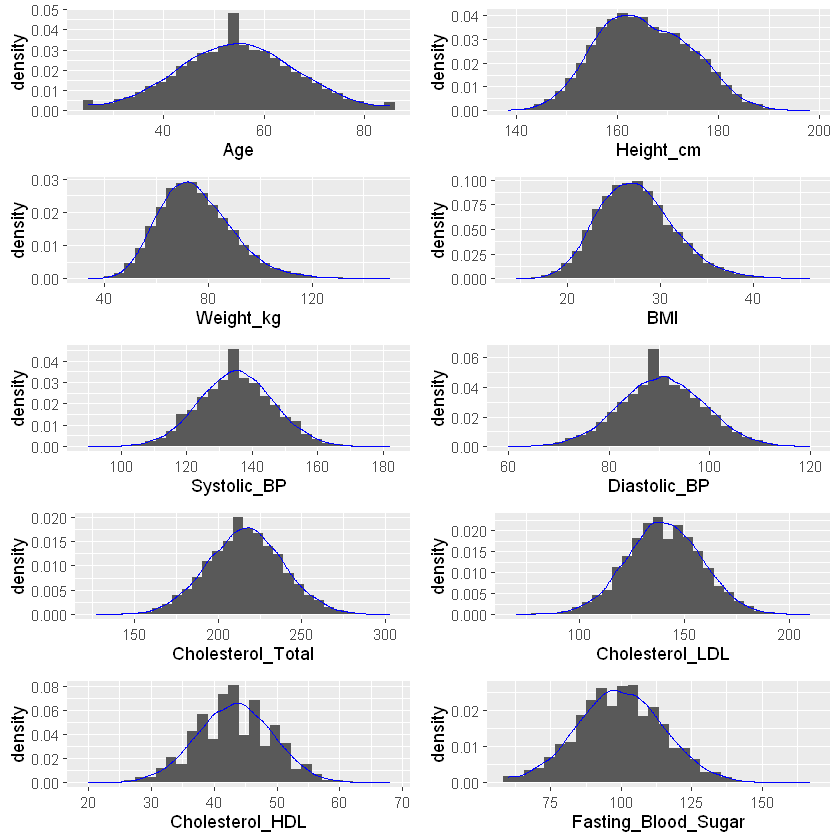

In [6]:
g1<-ggplot(health,aes(x=Age))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue") 

g2<-ggplot(health,aes(x=Height_cm))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g3<-ggplot(health,aes(x=Weight_kg))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g4<-ggplot(health,aes(x=BMI))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g5<-ggplot(health,aes(x=Systolic_BP))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g6<-ggplot(health,aes(x=Diastolic_BP))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g7<-ggplot(health,aes(x=Cholesterol_Total))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g8<-ggplot(health,aes(x=Cholesterol_LDL))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g9<-ggplot(health,aes(x=Cholesterol_HDL))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 

g10<-ggplot(health,aes(x=Fasting_Blood_Sugar))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 


grid.arrange(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,ncol=2,nrow=5)

#### Corrélation

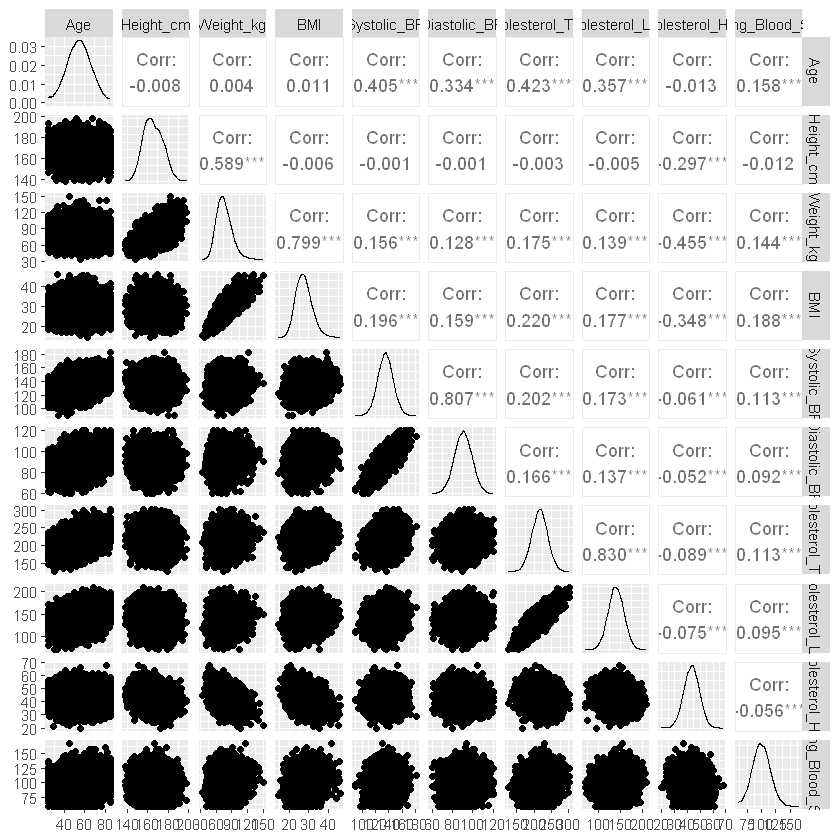

In [7]:
ggpairs(health[, c(2,4:12)])

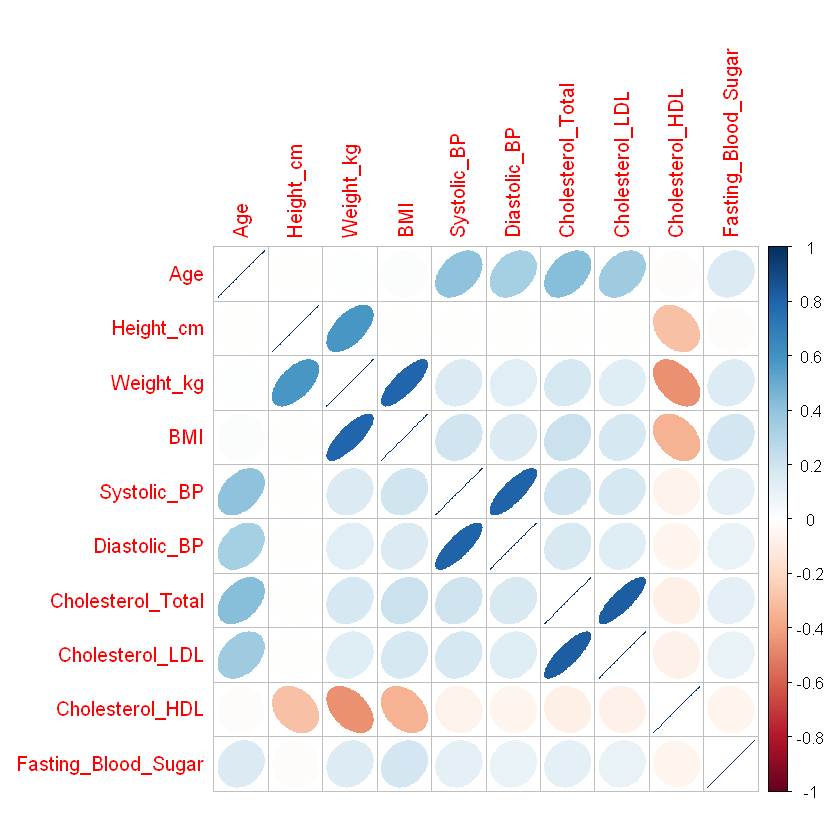

In [8]:
corrplot(cor(health[, c(2,4:12)]),method="ellipse")

### Variables Qualitatives

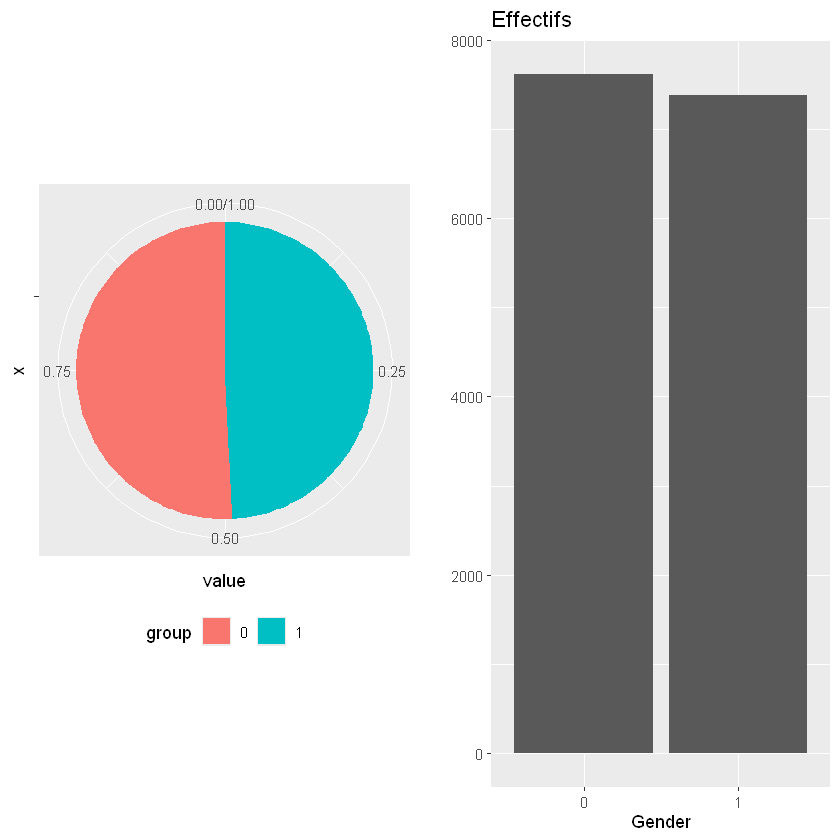

In [9]:

e2<-ggplot(health, aes(x=Gender))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

df2<- data.frame(group = levels(health$Gender),
                 value = as.vector(table(health$Gender))/nrow(health))
g2<-ggplot(df2, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")


grid.arrange(g2,e2,ncol=2)

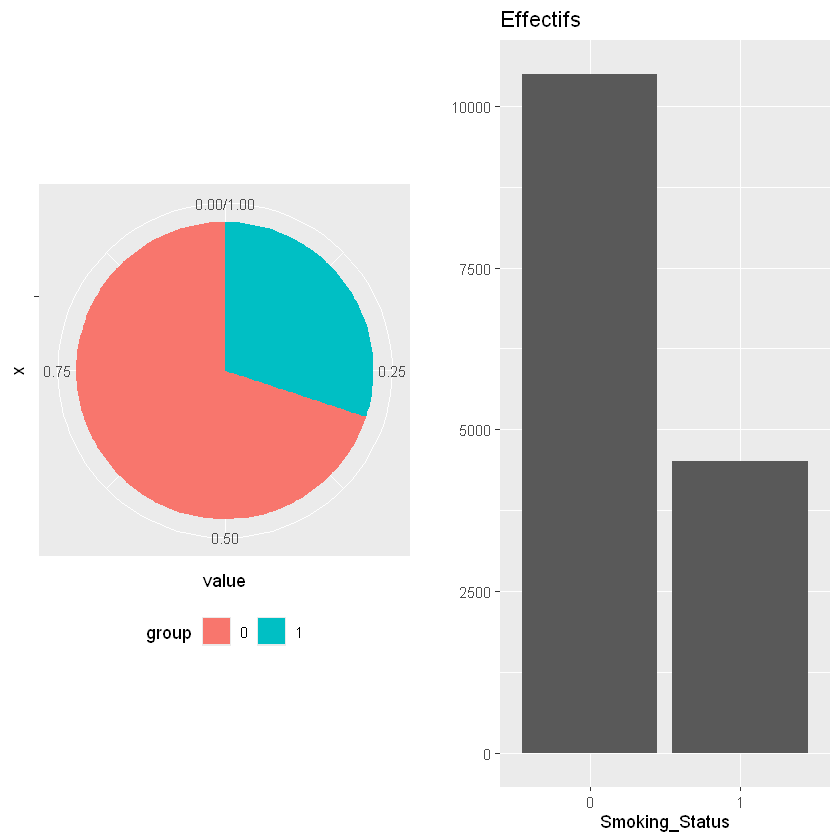

In [10]:
df3<- data.frame(group = levels(health$Smoking_Status),
                 value = as.vector(table(health$Smoking_Status))/nrow(health))
g3<-ggplot(df3, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e3<-ggplot(health, aes(x=Smoking_Status))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g3,e3,ncol=2)

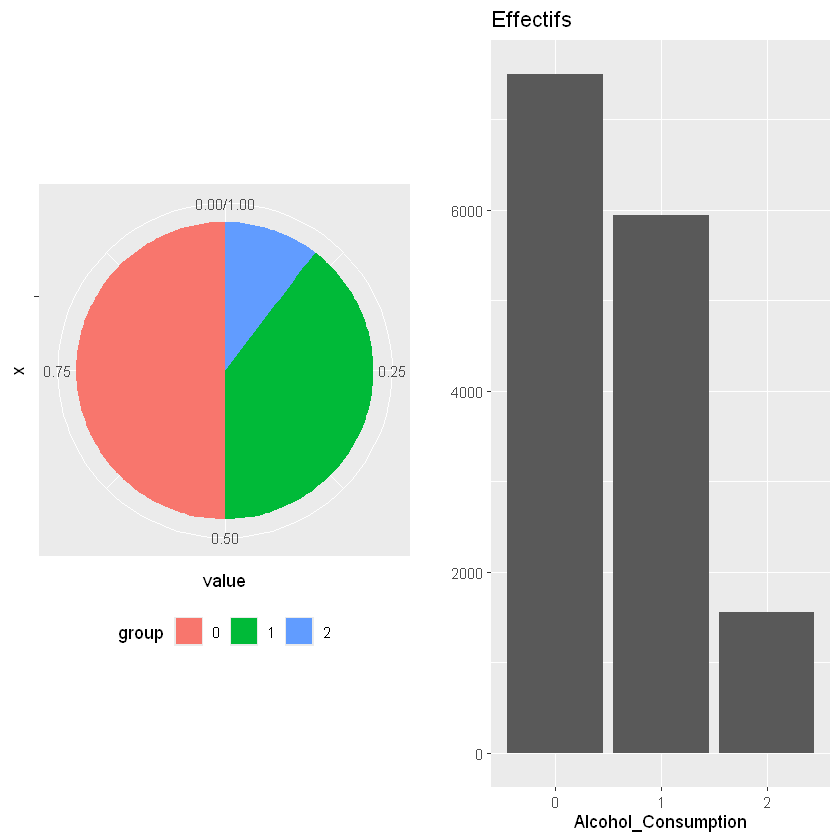

In [11]:
df4<- data.frame(group = levels(health$Alcohol_Consumption),
                 value = as.vector(table(health$Alcohol_Consumption))/nrow(health))
g4<-ggplot(df4, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e4<-ggplot(health, aes(x=Alcohol_Consumption))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g4,e4,ncol=2)

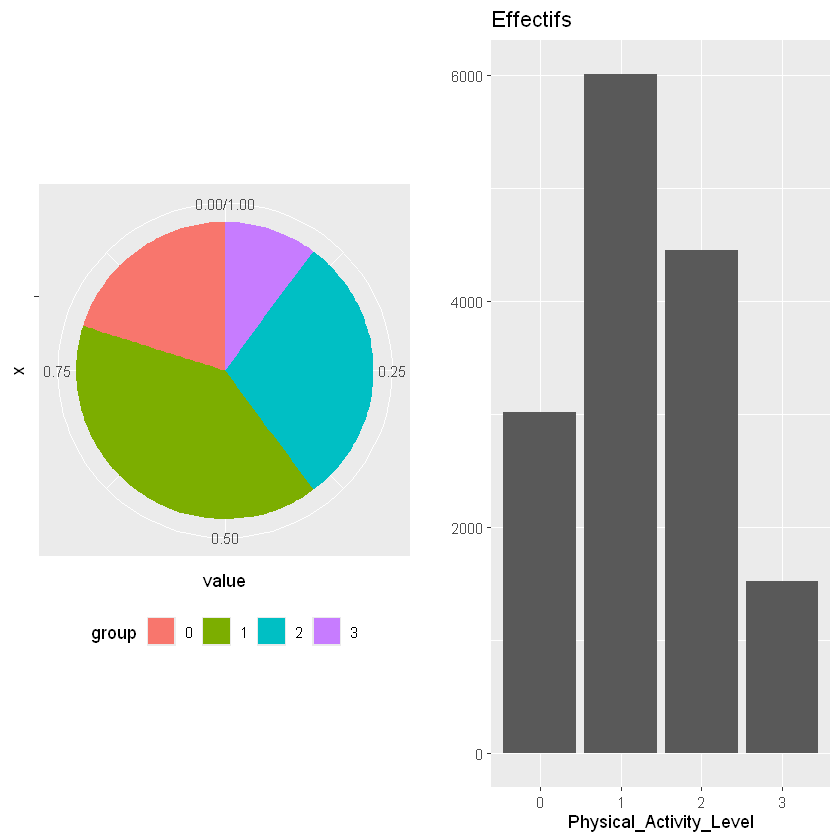

In [12]:
df5<- data.frame(group = levels(health$Physical_Activity_Level),
                 value = as.vector(table(health$Physical_Activity_Level))/nrow(health))
g5<-ggplot(df5, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e5<-ggplot(health, aes(x=Physical_Activity_Level))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g5,e5,ncol=2)

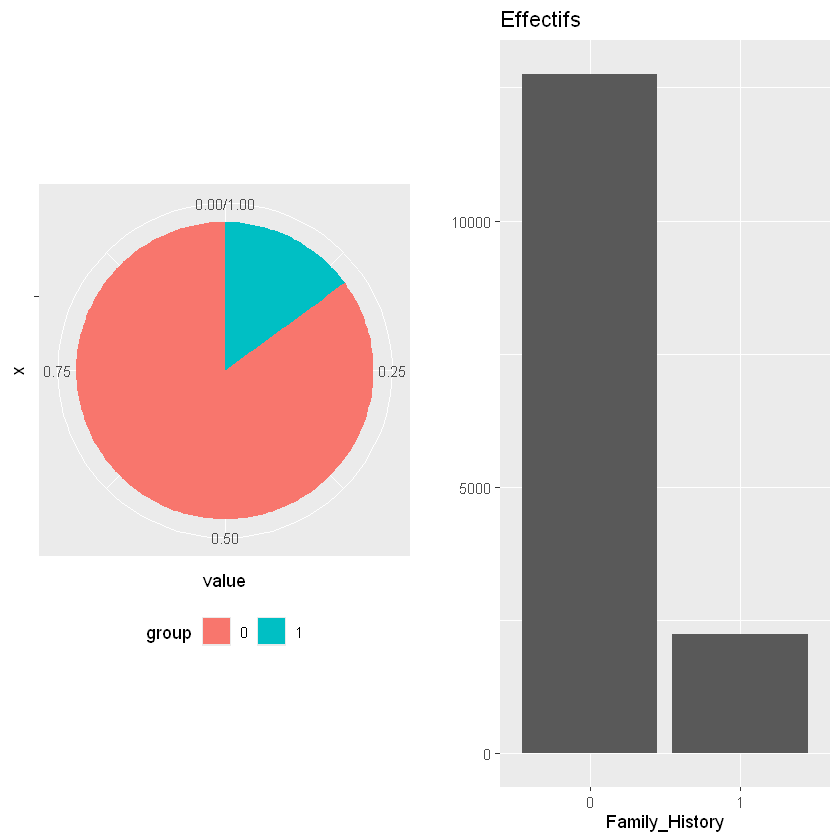

In [13]:
df6<- data.frame(group = levels(health$Family_History),
                 value = as.vector(table(health$Family_History))/nrow(health))
g6<-ggplot(df6, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e6<-ggplot(health, aes(x=Family_History))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g6,e6,ncol=2)

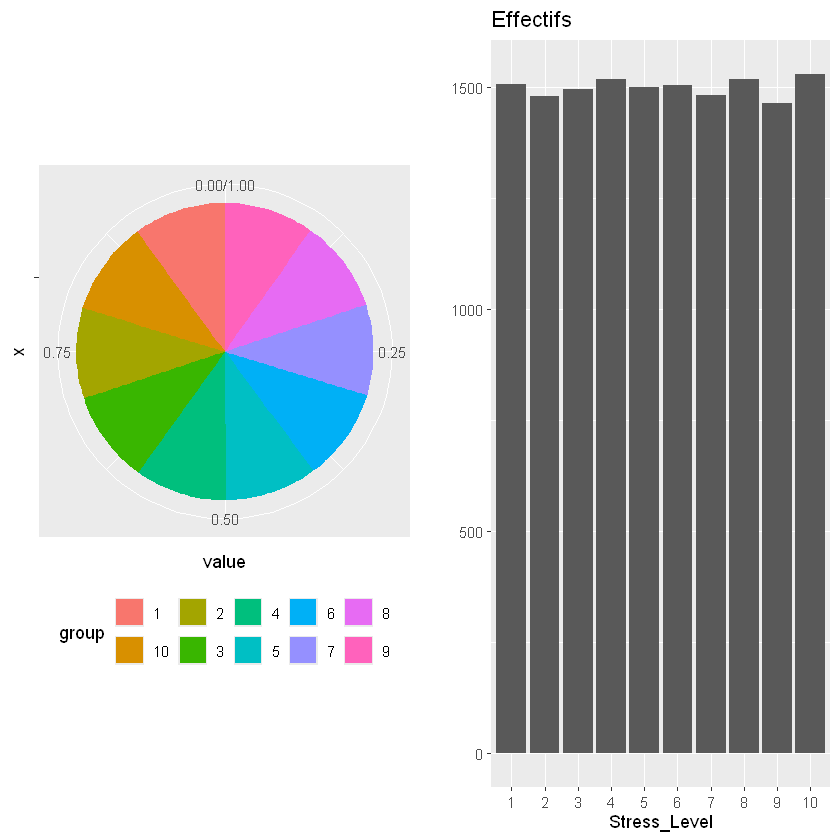

In [14]:
df7<- data.frame(group = levels(health$Stress_Level),
                 value = as.vector(table(health$Stress_Level))/nrow(health))
g7<-ggplot(df7, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e7<-ggplot(health, aes(x=Stress_Level))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g7,e7,ncol=2)

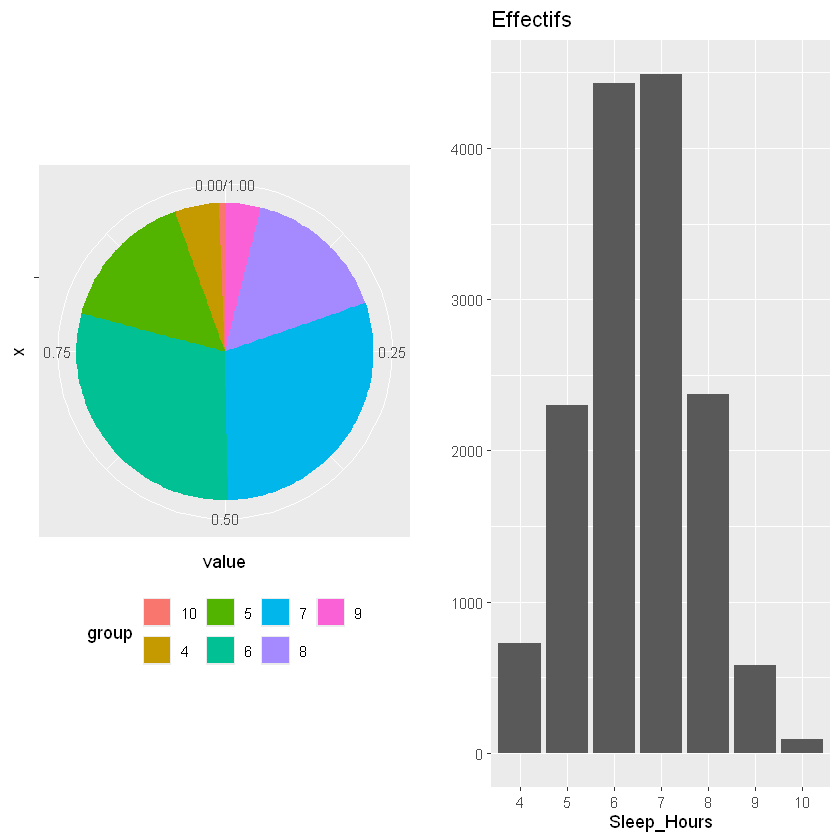

In [15]:
df8<- data.frame(group = levels(health$Sleep_Hours),
                 value = as.vector(table(health$Sleep_Hours))/nrow(health))
g8<-ggplot(df8, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e8<-ggplot(health, aes(x=Sleep_Hours))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g8,e8,ncol=2)

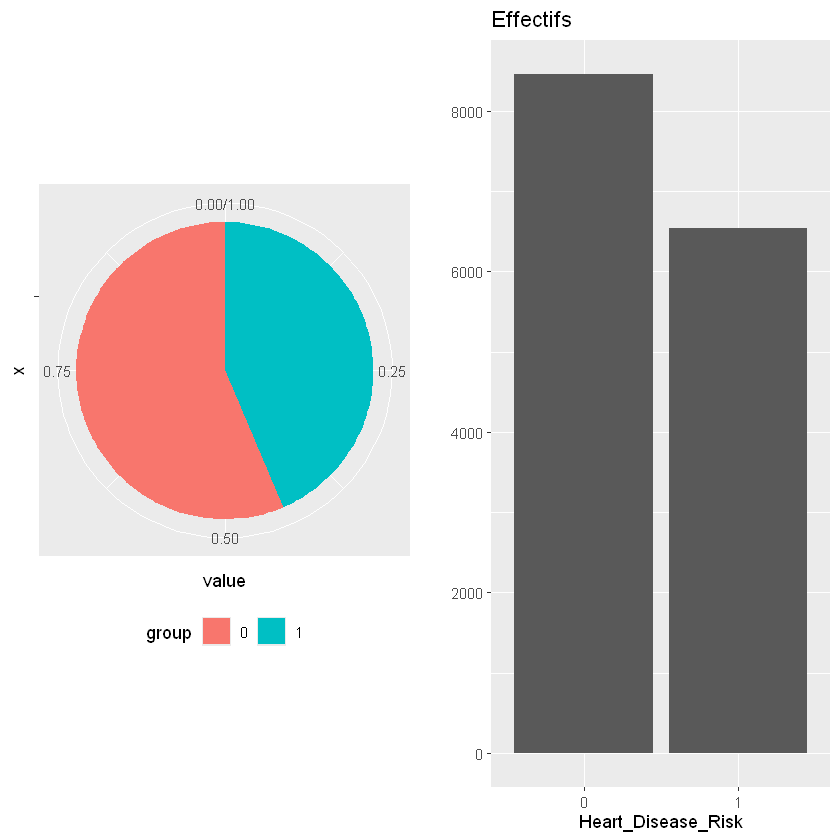

In [16]:
df9<- data.frame(group = levels(health$Heart_Disease_Risk),
                 value = as.vector(table(health$Heart_Disease_Risk))/nrow(health))
g9<-ggplot(df9, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")

e9<-ggplot(health, aes(x=Heart_Disease_Risk))+
           geom_bar()+
           ylab("")+
           ggtitle("Effectifs")

grid.arrange(g9,e9,ncol=2)

## Construction d'un échantillon test

In [21]:
set.seed(123) # initialisation du générateur
# Extraction des échantillons
test.ratio <- .2   # part de l'échantillon test
npop <- nrow(health) # nombre de lignes dans les données
nvar <- ncol(health) # nombre de colonnes
# taille de l'échantillon test
ntest <- ceiling(npop * test.ratio) 
# indices de l'échantillon test
test_HDR <- sample(1:npop, ntest)
# indices de l'échantillon d'apprentissage
appr_HDR <- setdiff(1:npop, test_HDR) 

Construction des échantillons pour la régression: prévision du risque de maladie cardiaque Heart_Disease_Risk

In [22]:
# construction de l'échantillon d'apprentissage
datappr_HDR <- health[appr_HDR, -11] 
# construction de l'échantillon test
datest_HDR <- health[test_HDR, -11] 
# vérification
str(datappr_HDR)
str(datest_HDR)
#summary(datappr0) 

'data.frame':	12000 obs. of  17 variables:
 $ Age                    : int  53 62 73 52 52 73 64 49 61 49 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 2 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  162 175 173 179 160 ...
 $ Weight_kg              : num  76.6 92.4 68.9 79.8 60.3 ...
 $ BMI                    : num  29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 33.9 ...
 $ Systolic_BP            : int  128 141 136 122 134 149 129 139 131 150 ...
 $ Diastolic_BP           : int  81 100 96 80 92 98 90 91 91 100 ...
 $ Cholesterol_Total      : int  203 173 193 236 225 260 237 227 206 188 ...
 $ Cholesterol_LDL        : int  119 124 117 153 155 166 160 138 139 129 ...
 $ Cholesterol_HDL        : int  38 45 45 41 48 46 44 37 38 43 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 1 1 1 2 1 1 2 1 1 1 ...
 $ Physical_Activity_Level: Factor w/ 4 levels "0","1","2","3": 2 1 2 3 2 3 3

In [23]:
# on normalise l'échantillon d'apprentissage
datappr_nHDR=datappr_HDR
datappr_nHDR[,-c(2,5,11,12,13,14,15,16,17)]=scale(datappr_HDR[,-c(2,5,11,12,13,14,15,16,17)])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr_nHDR=datest_HDR
datestr_nHDR[,-c(2,5,11,12,13,14,15,16,17)]=scale(datest_HDR[,-c(2,5,11,12,13,14,15,16,17)],
                            center=sapply(datappr_HDR[,-c(2,5,11,12,13,14,15,16,17)],mean), # on centre avec les moyennes de l'échantillon d'apprentissage
                            scale=sapply(datappr_HDR[,-c(2,5,11,12,13,14,15,16,17)],sd)) # on réduit avec les écart-types de l'échantillon d'apprentissage
summary(datappr_nHDR)
summary(datestr_nHDR)


      Age           Gender     Height_cm          Weight_kg       
 Min.   :-2.48850   0:6087   Min.   :-2.91289   Min.   :-2.60543  
 1st Qu.:-0.63473   1:5913   1st Qu.:-0.75343   1st Qu.:-0.71330  
 Median : 0.03937            Median :-0.06979   Median :-0.09676  
 Mean   : 0.00000            Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.71347            3rd Qu.: 0.72238   3rd Qu.: 0.61900  
 Max.   : 2.56724            Max.   : 3.55463   Max.   : 4.76469  
                                                                  
      BMI         Systolic_BP         Diastolic_BP      Cholesterol_Total
 Min.   :14.50   Min.   :-4.008428   Min.   :-3.63179   Min.   :-3.7324  
 1st Qu.:24.50   1st Qu.:-0.719534   1st Qu.:-0.65753   1st Qu.:-0.6751  
 Median :27.10   Median :-0.008422   Median : 0.05629   Median :-0.0104  
 Mean   :27.41   Mean   : 0.000000   Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.:30.00   3rd Qu.: 0.702690   3rd Qu.: 0.65115   3rd Qu.: 0.6542  
 Max.   :46.10   Max

      Age            Gender     Height_cm           Weight_kg       
 Min.   :-2.488498   0:1535   Min.   :-2.912890   Min.   :-2.93851  
 1st Qu.:-0.718989   1:1465   1st Qu.:-0.731731   1st Qu.:-0.68495  
 Median : 0.039372            Median :-0.069787   Median :-0.05424  
 Mean   : 0.002268            Mean   :-0.003441   Mean   : 0.03092  
 3rd Qu.: 0.713470            3rd Qu.: 0.725088   3rd Qu.: 0.63317  
 Max.   : 2.567241            Max.   : 3.522072   Max.   : 5.31037  
                                                                    
      BMI         Systolic_BP         Diastolic_BP       Cholesterol_Total  
 Min.   :15.30   Min.   :-3.563983   Min.   :-3.631793   Min.   :-3.953987  
 1st Qu.:24.77   1st Qu.:-0.630645   1st Qu.:-0.657530   1st Qu.:-0.675051  
 Median :27.30   Median :-0.008422   Median : 0.056293   Median :-0.010402  
 Mean   :27.58   Mean   : 0.010185   Mean   : 0.008586   Mean   : 0.002936  
 3rd Qu.:30.00   3rd Qu.: 0.702690   3rd Qu.: 0.651145   3rd Qu

Construction des échantillons pour la discrimination: prévision de Cholesterol_LDL

In [25]:
#On enlève patient_ID
health <-  health %>% dplyr::select(-Heart_Disease_Risk)

In [26]:
# construction de l'échantillon d'apprentissage
datappr_LDL <- health[appr_HDR,-2]
# construction de l'échantillon test 
datest_LDL <- health[test_HDR,-2] 

# vérification
str(datappr_LDL)
str(datest_LDL)
#summary(datappq)

'data.frame':	12000 obs. of  16 variables:
 $ Age                    : int  53 62 73 52 52 73 64 49 61 49 ...
 $ Height_cm              : num  162 175 173 179 160 ...
 $ Weight_kg              : num  76.6 92.4 68.9 79.8 60.3 ...
 $ BMI                    : num  29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 33.9 ...
 $ Systolic_BP            : int  128 141 136 122 134 149 129 139 131 150 ...
 $ Diastolic_BP           : int  81 100 96 80 92 98 90 91 91 100 ...
 $ Cholesterol_Total      : int  203 173 193 236 225 260 237 227 206 188 ...
 $ Cholesterol_LDL        : int  119 124 117 153 155 166 160 138 139 129 ...
 $ Cholesterol_HDL        : int  38 45 45 41 48 46 44 37 38 43 ...
 $ Fasting_Blood_Sugar    : int  116 90 81 79 103 103 108 90 103 106 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 1 1 1 2 1 1 2 1 1 1 ...
 $ Physical_Activity_Level: Factor w/ 4 levels "0","1","2","3": 2 1 2 3 2 3 3 3 3 1 

In [27]:
# on normalise l'échantillon d'apprentissage
datappr_nLDL=datappr_LDL
datappr_nLDL[,-c(2,5,11,12,13,14,15,16,17)]=scale(datappr_LDL[,-c(2,5,11,12,13,14,15,16,17)])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr_nLDL=datest_LDL
datestr_nLDL[,-c(2,5,11,12,13,14,15,16,17)]=scale(datest_LDL[,-c(2,5,11,12,13,14,15,16,17)],
                            center=sapply(datappr_LDL[,-c(2,5,11,12,13,14,15,16,17)],mean), # on centre avec les moyennes de l'échantillon d'apprentissage
                            scale=sapply(datappr_LDL[,-c(2,5,11,12,13,14,15,16,17)],sd)) # on réduit avec les écart-types de l'échantillon d'apprentissage
summary(datappr_nLDL)
summary(datestr_nLDL)


      Age             Height_cm       Weight_kg             BMI          
 Min.   :-2.48850   Min.   :138.5   Min.   :-2.60543   Min.   :-3.12459  
 1st Qu.:-0.63473   1st Qu.:158.4   1st Qu.:-0.71330   1st Qu.:-0.70467  
 Median : 0.03937   Median :164.7   Median :-0.09676   Median :-0.07549  
 Mean   : 0.00000   Mean   :165.3   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.71347   3rd Qu.:172.0   3rd Qu.: 0.61900   3rd Qu.: 0.62628  
 Max.   : 2.56724   Max.   :198.1   Max.   : 4.76469   Max.   : 4.52235  
                                                                         
  Systolic_BP     Diastolic_BP      Cholesterol_Total Cholesterol_LDL   
 Min.   : 90.0   Min.   :-3.63179   Min.   :-3.7324   Min.   :-3.92689  
 1st Qu.:127.0   1st Qu.:-0.65753   1st Qu.:-0.6751   1st Qu.:-0.69028  
 Median :135.0   Median : 0.05629   Median :-0.0104   Median :-0.02064  
 Mean   :135.1   Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.00000  
 3rd Qu.:143.0   3rd Qu.: 0.65115   3rd Qu.

      Age              Height_cm       Weight_kg             BMI          
 Min.   :-2.488498   Min.   :138.5   Min.   :-2.93851   Min.   :-2.93099  
 1st Qu.:-0.718989   1st Qu.:158.6   1st Qu.:-0.68495   1st Qu.:-0.63812  
 Median : 0.039372   Median :164.7   Median :-0.05424   Median :-0.02710  
 Mean   : 0.002268   Mean   :165.3   Mean   : 0.03092   Mean   : 0.04128  
 3rd Qu.: 0.713470   3rd Qu.:172.0   3rd Qu.: 0.63317   3rd Qu.: 0.62628  
 Max.   : 2.567241   Max.   :197.8   Max.   : 5.31037   Max.   : 4.40135  
                                                                          
  Systolic_BP     Diastolic_BP       Cholesterol_Total   Cholesterol_LDL    
 Min.   : 95.0   Min.   :-3.631793   Min.   :-3.953987   Min.   :-3.871085  
 1st Qu.:128.0   1st Qu.:-0.657530   1st Qu.:-0.675051   1st Qu.:-0.634481  
 Median :135.0   Median : 0.056293   Median :-0.010402   Median :-0.020643  
 Mean   :135.2   Mean   : 0.008586   Mean   : 0.002936   Mean   :-0.004088  
 3rd Qu.:143.0 

Graphe des résidus

In [28]:
gplot.res <- function(x, y, titre = "titre"){
    ggplot(data.frame(x=x, y=y),aes(x,y))+
    geom_point(col = "blue")+xlim(-5, 5)+ylim(-5, 5)+
    ylab("Résidus")+ xlab("Valeurs prédites")+
    ggtitle(titre)+
    geom_hline(yintercept = 0,col="green")
}

# Prévision par modèle linéaire gaussien

## Modèle linéaire

### Sans sélection de variables

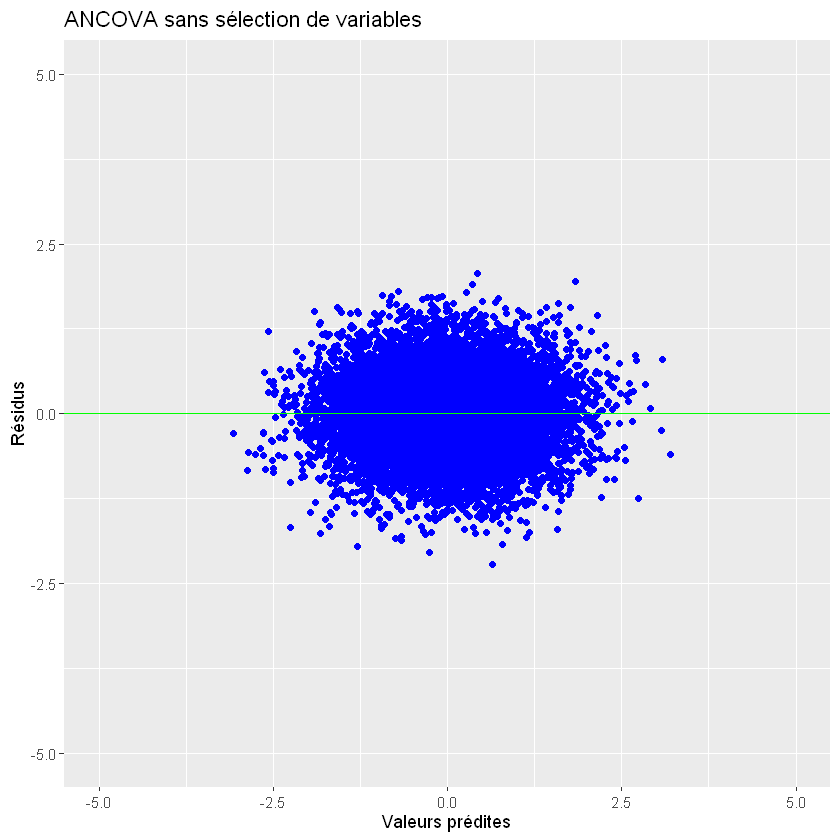

In [29]:
# estimation du modèle sans interaction
reg.lm <-aov(Cholesterol_LDL ~ . , data = datappr_nLDL)
# Extraction des résidus et des valeurs ajustées de ce modèle
res.lm <- reg.lm$residuals
fit.lm <- reg.lm$fitted.values
# Graphe des résidus. 
gplot.res(fit.lm,res.lm,"ANCOVA sans sélection de variables")

Heart_Disease_Risk étant une variable qualitative binaire, on va utiliser un modèle logit.

## [Prévision par modèle binomial](http://wikistat.fr/pdf/st-m-app-rlogit.pdf)

### Régression logistique sans interaction

In [30]:
# estimation du modèle complet
log.lm <- glm(Heart_Disease_Risk ~. , data = datappr_nHDR, family = binomial)
# significativité des paramètres
anova(log.lm, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16447.54,NA
Age,1,3.258555e+02,11998,16121.69,7.682328e-73
Gender,1,2.863548e-01,11997,16121.40,5.925660e-01
Height_cm,1,1.325186e+00,11996,16120.07,2.496635e-01
Weight_kg,1,2.207439e+02,11995,15899.33,6.224608e-50
BMI,1,4.263602e+00,11994,15895.07,3.893727e-02
Systolic_BP,1,1.850425e+02,11993,15710.02,3.841669e-42
Diastolic_BP,1,3.787130e-04,11992,15710.02,9.844737e-01
Cholesterol_Total,1,1.981823e+01,11991,15690.21,8.516634e-06


In [31]:
# Recherche d'un modèle optimal au sens d'Akaïke
log.lm.step <- step(log.lm, direction = "backward")

Start:  AIC=12890.26
Heart_Disease_Risk ~ Age + Gender + Height_cm + Weight_kg + BMI + 
    Systolic_BP + Diastolic_BP + Cholesterol_Total + Cholesterol_LDL + 
    Cholesterol_HDL + Smoking_Status + Alcohol_Consumption + 
    Physical_Activity_Level + Family_History + Stress_Level + 
    Sleep_Hours

                          Df Deviance   AIC
- Alcohol_Consumption      2    12826 12888
- Diastolic_BP             1    12824 12888
- Height_cm                1    12824 12888
- Weight_kg                1    12824 12888
- Gender                   1    12825 12889
- BMI                      1    12826 12890
- Cholesterol_HDL          1    12826 12890
- Cholesterol_Total        1    12826 12890
<none>                          12824 12890
- Sleep_Hours              6    12849 12903
- Cholesterol_LDL          1    12853 12917
- Systolic_BP              1    12914 12978
- Age                      1    12921 12985
- Stress_Level             9    13006 13054
- Physical_Activity_Level  3    13242 

In [32]:
# Modèle obtenu
anova(log.lm.step, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16447.54,NA
Age,1,325.85545,11998,16121.69,7.682328e-73
BMI,1,224.66038,11997,15897.03,8.707308e-51
Systolic_BP,1,185.42245,11996,15711.60,3.173758e-42
Cholesterol_LDL,1,40.67575,11995,15670.93,1.797035e-10
Smoking_Status,1,1602.32052,11994,14068.61,0.000000e+00
Physical_Activity_Level,3,391.36206,11991,13677.24,1.644914e-84
Family_History,1,639.78466,11990,13037.46,3.721969e-141
Stress_Level,9,182.76625,11981,12854.69,1.339581e-34


In [33]:
# matrice de confusion de l'échantillon d'apprentissage et erreur apparente
table(log.lm.step$fitted.values > 0.5, datappr_nHDR[, "Heart_Disease_Risk"])

       
           0    1
  FALSE 5437 1874
  TRUE  1313 3376

### Régression logistique avec interactions

In [34]:
# régression avec le modèle minimum
log.qm <- glm(Heart_Disease_Risk ~ 1, data = datappr_nHDR,family = binomial)
# algorithme stepwise en précisant le plus grand 
# modèle possible
log.qm.step1 <- step(log.qm, direction = "both",
    scope = list(lower = ~1, upper = ~ (Age + Gender + Height_cm + Weight_kg + BMI + 
    Systolic_BP + Diastolic_BP + Cholesterol_Total + Cholesterol_LDL + 
    Cholesterol_HDL + Smoking_Status + Alcohol_Consumption + 
    Physical_Activity_Level + Family_History + Stress_Level + 
    Sleep_Hours)^2), 
    family=binomial)

Start:  AIC=16449.54
Heart_Disease_Risk ~ 1

                          Df Deviance   AIC
+ Smoking_Status           1    14930 14934
+ Systolic_BP              1    15951 15955
+ Family_History           1    15968 15972
+ Age                      1    16122 16126
+ Diastolic_BP             1    16122 16126
+ Physical_Activity_Level  3    16140 16148
+ BMI                      1    16226 16230
+ Cholesterol_LDL          1    16232 16236
+ Cholesterol_Total        1    16238 16242
+ Weight_kg                1    16290 16294
+ Stress_Level             9    16298 16318
+ Cholesterol_HDL          1    16406 16410
+ Sleep_Hours              6    16424 16438
<none>                          16448 16450
+ Height_cm                1    16446 16450
+ Gender                   1    16447 16451
+ Alcohol_Consumption      2    16447 16453

Step:  AIC=14934.37
Heart_Disease_Risk ~ Smoking_Status

                          Df Deviance   AIC
+ Family_History           1    14375 14381
+ Systolic_BP    

In [35]:
anova(log.qm.step1, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16447.54,NA
Smoking_Status,1,1517.173800,11998,14930.37,0.000000e+00
Family_History,1,555.174671,11997,14375.19,9.425372e-123
Systolic_BP,1,575.227733,11996,13799.96,4.094051e-127
Physical_Activity_Level,3,399.825834,11993,13400.14,2.414799e-86
Stress_Level,9,180.969728,11984,13219.17,3.178560e-34
Cholesterol_LDL,1,161.854929,11983,13057.31,4.450233e-37
BMI,1,106.144474,11982,12951.17,6.855075e-25
Age,1,96.476353,11981,12854.69,9.031612e-23


### Prévision de l'échantillon test

In [36]:
# Prévision du modèle quadratique
pred.log <- predict(log.qm.step1, newdata = datestr_nHDR, type = "response")
# Matrice de confusion pour la prévision du 
# dépassement de seuil
table(pred.log > 0.5, datestr_nHDR[, "Heart_Disease_Risk"])

       
           0    1
  FALSE 1380  482
  TRUE   330  808

# [Analyse discriminante](http://wikistat.fr/pdf/st-m-app-add.pdf)

In [38]:
# analyse discriminante linéaire
disc.lda=lda(Heart_Disease_Risk~.,data=datappr_nHDR) 
# analyse discriminante quadratique 
disc.qda=qda(Heart_Disease_Risk~.,data=datappr_nHDR) 
# k plus proches voisins
disc.knn=knn(datappr_nHDR[,c(-17)],datappr_nHDR[,c(-17)],datappr_nHDR$Heart_Disease_Risk,k=10) 

In [41]:
library(caret)
lda.fit<-train(Heart_Disease_Risk~.,data=datappr_nHDR,method="lda")
qda.fit<-train(Heart_Disease_Risk~.,data=datappr_nHDR,method="qda")
knn.fit<-train(Heart_Disease_Risk~.,data=datappr_nHDR,method="knn")

Warning message:
"le package 'caret' a été compilé avec la version R 4.5.3"
Le chargement a nécessité le package : lattice


Attachement du package : 'caret'


L'objet suivant est masqué depuis 'package:purrr':

    lift




### Estimation de l'erreur de prévision par validation croisée

#### Sans utiliser la librairie `caret`

In [42]:
# erreur par validation croisée  en analyse discriminante linéaire
disc.lda=lda(Heart_Disease_Risk~.,data=datappr_nHDR,CV=T) 
# estimer le taux d'erreur à partir de la matrice de confusion
t1=table(data=datappr_nHDR[,"Heart_Disease_Risk"],disc.lda$class)  
t1

# Faux négatifs : pour chaque ligne, tout ce qui n'est pas sur la diagonale
FN <- rowSums(t1) - diag(t1)

# Faux positifs : pour chaque colonne, tout ce qui n'est pas sur la diagonale
FP <- colSums(t1) - diag(t1)

# Total sur toutes les classes
total_FN <- sum(FN)
total_FP <- sum(FP)

m1=(total_FN+total_FP)/sum(t1)*100
m1

    
data    0    1
   0 5472 1278
   1 1944 3306

[1] 53.7

In [43]:
cat("Erreur CV — LDA:", round(m1, 1), "%\n")

Erreur CV — LDA: 53.7 %


In [45]:
# analyse discriminante quadratique
disc.qda=qda(Heart_Disease_Risk~.,data=datappr_nHDR,CV=T)  
t2=table(datappr_nHDR[,"Heart_Disease_Risk"],disc.qda$class)
t2
# Faux négatifs : pour chaque ligne, tout ce qui n'est pas sur la diagonale
FN <- rowSums(t2) - diag(t2)

# Faux positifs : pour chaque colonne, tout ce qui n'est pas sur la diagonale
FP <- colSums(t2) - diag(t2)

# Total sur toutes les classes
total_FN <- sum(t2) - sum(diag(t2))   # tout sauf les bons
total_FP <- sum(t2) - sum(diag(t2))   # même chose si on prend toutes les classes

m1=(total_FN+total_FP)/sum(t2)*100
m1

   
       0    1
  0 4765 1985
  1 1698 3552

[1] 61.38333

In [46]:
cat("Erreur CV — LDA:", round(m1, 1), "%\n")

Erreur CV — LDA: 61.4 %


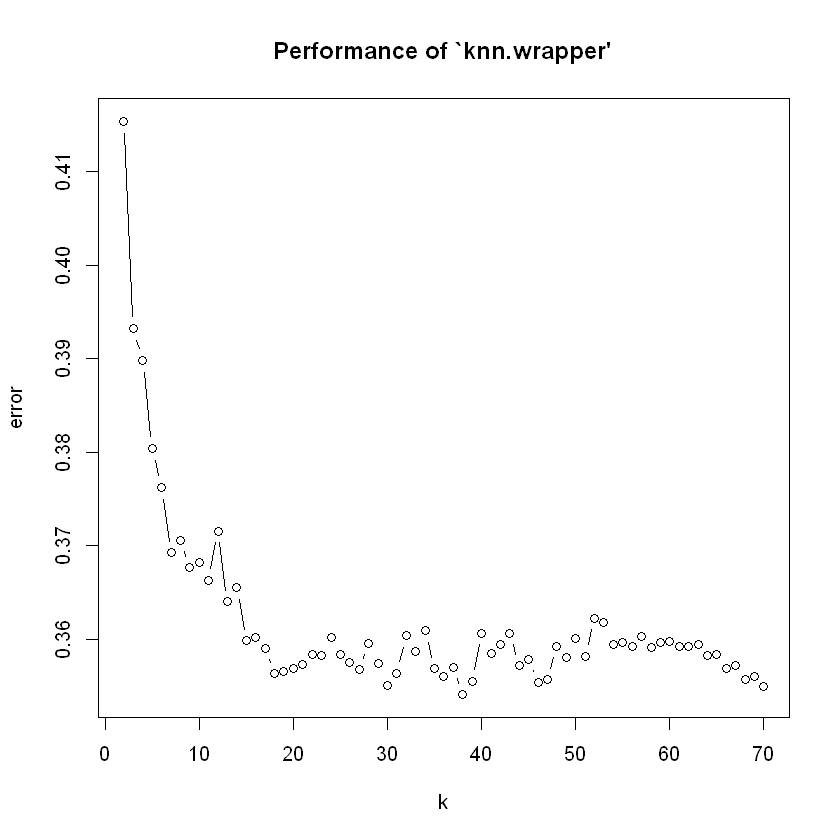

In [52]:
# k plus proches voisins: optimisation de k
library(e1071)
plot(tune.knn(as.matrix(datappr_nHDR[,c(-17)]),as.factor(datappr_nHDR[,17]),k=2:70))

#### Avec la librairie `caret`

In [65]:
# Validation croisée avec 10 folds
param_train<-trainControl(method="cv",number=38)
# erreur par validation croisée  en analyse discriminante linéaire
lda.fit <- train(Heart_Disease_Risk~.,data=datappr_nHDR,method="lda",trControl=param_train)
# estimer le taux d'erreur à partir de la matrice de confusion
table(datappr_nHDR[,"Heart_Disease_Risk"],predict(lda.fit,datappr_nHDR[,c(-17)])) 

   
       0    1
  0 5482 1268
  1 1931 3319

In [66]:
# erreur par validation croisée  en analyse discriminante quadratique
qda.fit <- train(Heart_Disease_Risk~.,data=datappr_nHDR,method="qda",trControl=param_train)
# estimer le taux d'erreur à partir de la matrice de confusion
table(datappr_nHDR[,"Heart_Disease_Risk"],predict(qda.fit,datappr_nHDR[,c(-17)])) 

   
       0    1
  0 4837 1913
  1 1624 3626

In [67]:
# erreur par validation croisée  en kNN
knn.fit <- train(Heart_Disease_Risk~.,data=datappr_nHDR,method="knn",trControl=param_train,tuneLength=20)
# estimer le taux d'erreur à partir de la matrice de confusion
table(datappr_nHDR[,"Heart_Disease_Risk"],predict(knn.fit,datappr_nHDR[,c(-17)])) 

   
       0    1
  0 5759  991
  1 2816 2434

### Prévision de l'échantillon test

#### Matrices de confusion

In [68]:
## méthode LDA
table(predict(lda.fit,datestr_nHDR),datestr_nHDR[,"Heart_Disease_Risk"])
sum(predict(lda.fit,datestr_nHDR)!=datestr_nHDR[,"Heart_Disease_Risk"])/nrow(datestr_nHDR)

   
       0    1
  0 1394  495
  1  316  795

[1] 0.2703333

In [69]:
## méthode QDA
table(predict(qda.fit,datestr_nHDR),datestr_nHDR[,"Heart_Disease_Risk"])
sum(predict(qda.fit,datestr_nHDR)!=datestr_nHDR[,"Heart_Disease_Risk"])/nrow(datestr_nHDR)

   
       0    1
  0 1229  460
  1  481  830

[1] 0.3136667

In [70]:
## méthode KNN
table(predict(knn.fit,datestr_nHDR),datestr_nHDR[,"Heart_Disease_Risk"])
sum(predict(knn.fit,datestr_nHDR)!=datestr_nHDR[,"Heart_Disease_Risk"])/nrow(datestr_nHDR)

   
       0    1
  0 1411  742
  1  299  548

[1] 0.3466667

In [71]:
confusionMatrix(predict(knn.fit,datestr_nHDR),datestr_nHDR[,"Heart_Disease_Risk"])

Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1412  741
         1  298  549
                                          
               Accuracy : 0.6537          
                 95% CI : (0.6363, 0.6707)
    No Information Rate : 0.57            
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.2624          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.8257          
            Specificity : 0.4256          
         Pos Pred Value : 0.6558          
         Neg Pred Value : 0.6482          
             Prevalence : 0.5700          
         Detection Rate : 0.4707          
   Detection Prevalence : 0.7177          
      Balanced Accuracy : 0.6257          
                                          
       'Positive' Class : 0               
                        

#### Courbes ROC

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



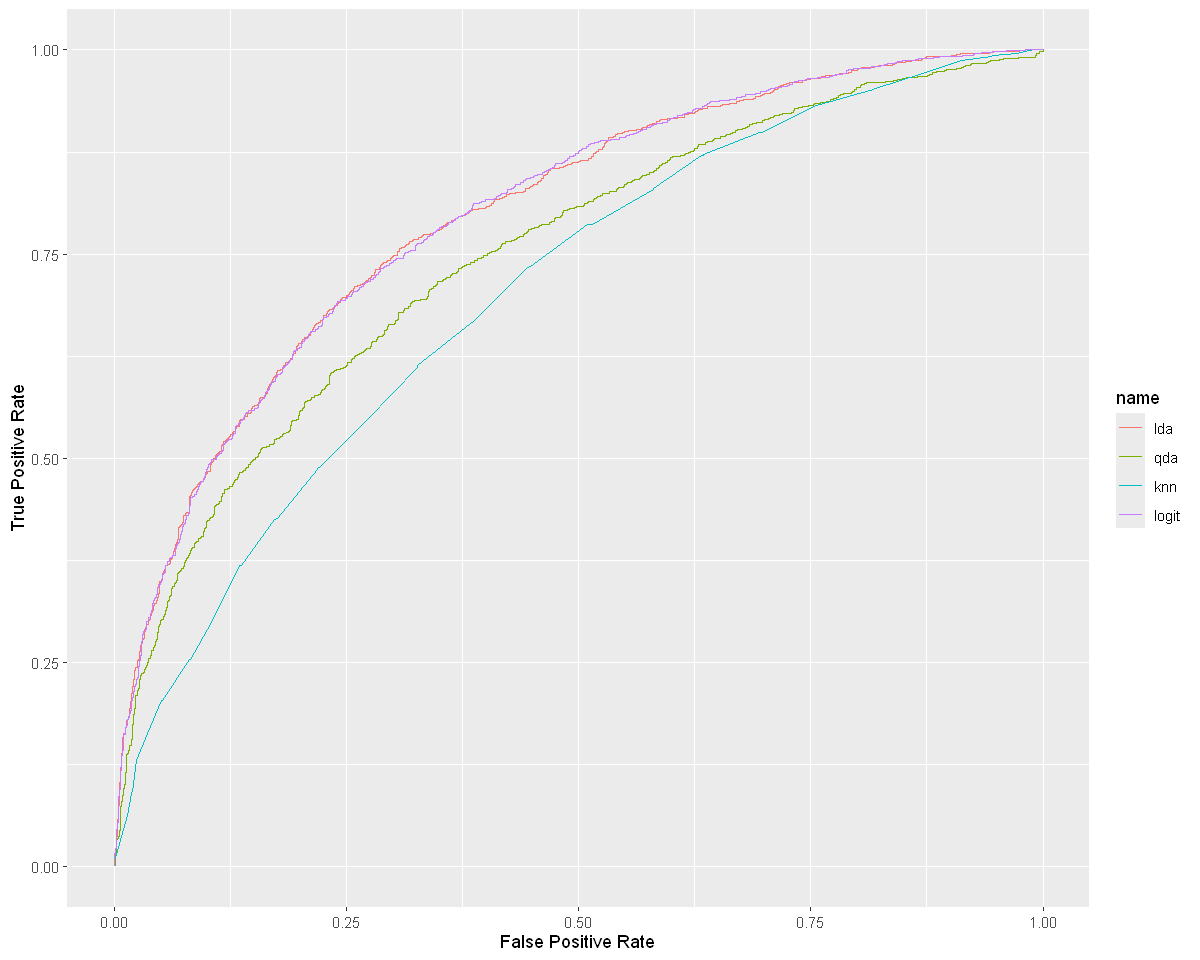

In [72]:
rocobjlda<-roc(datestr_nHDR$Heart_Disease_Risk,predict(lda.fit,datestr_nHDR,type="prob")[,2])
rocobjqda<-roc(datestr_nHDR$Heart_Disease_Risk,predict(qda.fit,datestr_nHDR,type="prob")[,2])
rocobjknn<-roc(datestr_nHDR$Heart_Disease_Risk,predict(knn.fit,datestr_nHDR,type="prob")[,2])
rocobjlogit<-roc(datestr_nHDR[, "Heart_Disease_Risk"],predict(log.qm.step1, newdata = datestr_nHDR, type="response"))

options(repr.plot.width = 10, repr.plot.height = 8)
ggroc(list(lda=rocobjlda,qda=rocobjqda,knn=rocobjknn,logit=rocobjlogit),legacy.axes=T)+
  xlab("False Positive Rate")+
  ylab("True Positive Rate")